Customer Churn Prediction using Machine Learning

This project predicts whether a customer will churn based on the fields like Age, Income,Purchase,
and membership type.

The models used are:
1.Logistic regression
2.Random forest
3.XGBoost

In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [4]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [5]:
data=pd.read_csv(r"customer_data_with_churn.csv")
data.head()

,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Membership_Level,Purchase_Frequency,Churn_Status
0,CUST1000,Connor Rowland,40,Female,52777,27,Gold,5.2,0
1,CUST1001,Cameron Miles MD,28,Female,65910,84,Basic,12.2,0
2,CUST1002,Dennis Price,63,Male,56731,51,Silver,2.9,1
3,CUST1003,Jessica Jones,23,Female,40559,56,Platinum,11.1,0
4,CUST1004,Kevin Bauer,38,Male,79675,74,Basic,10.7,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          2000 non-null   object 
 1   Name                2000 non-null   object 
 2   Age                 2000 non-null   int64  
 3   Gender              2000 non-null   object 
 4   Annual_Income       2000 non-null   int64  
 5   Spending_Score      2000 non-null   int64  
 6   Membership_Level    2000 non-null   object 
 7   Purchase_Frequency  2000 non-null   float64
 8   Churn_Status        2000 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


In [7]:
data.shape

(2000, 9)

In [8]:
data.describe()

,Age,Annual_Income,Spending_Score,Purchase_Frequency,Churn_Status
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,43.57150,59849.506000,50.469500,8.000450,0.332500
std,15.13137,14451.507584,29.059289,3.987447,0.471227
min,18.00000,9857.000000,1.000000,1.000000,0.000000
25%,30.00000,49818.500000,25.000000,4.600000,0.000000
50%,43.00000,60036.500000,51.000000,8.000000,0.000000
75%,57.00000,69631.500000,76.000000,11.500000,1.000000
max,69.00000,110053.000000,100.000000,15.000000,1.000000


In [9]:
data.isnull().sum()

CustomerID            0
Name                  0
Age                   0
Gender                0
Annual_Income         0
Spending_Score        0
Membership_Level      0
Purchase_Frequency    0
Churn_Status          0
dtype: int64

In [10]:
data["Churn_Status"].value_counts()

Churn_Status
0    1335
1     665
Name: count, dtype: int64

Here, the unnecessary columns such as CustomerID and Name are removed. Categorical features like Gender and Membership level are converted into numerical so that ML algorithms can process them.

In [11]:
data=data.drop(['CustomerID','Name'],axis=1,errors='ignore')

In [12]:
data['Gender']=data['Gender'].astype('category').cat.codes
data['Membership_Level']=data['Membership_Level'].astype('category').cat.codes

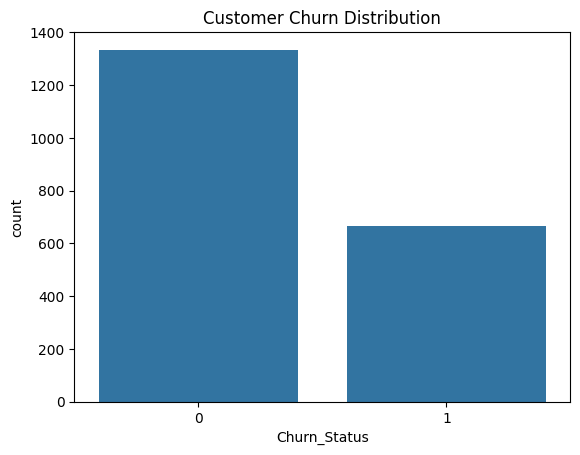

In [13]:
sns.countplot(x='Churn_Status',data=data)
plt.title("Customer Churn Distribution")
plt.show()

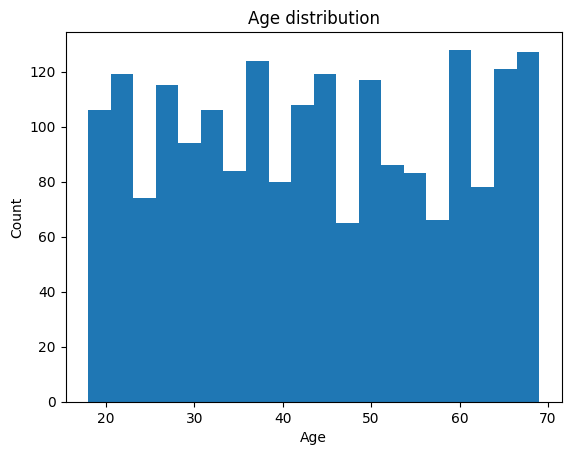

In [14]:
plt.hist(data['Age'],bins=20)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

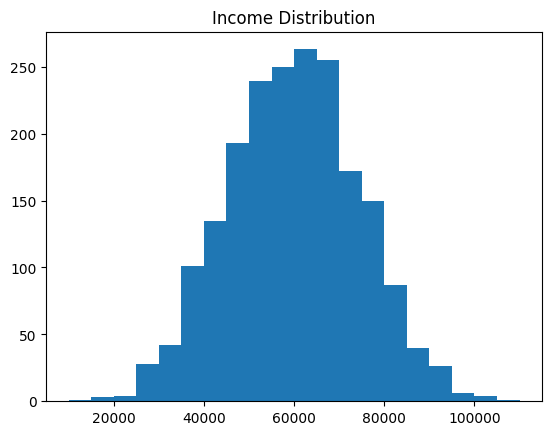

In [15]:
plt.hist(data['Annual_Income'],bins=20)
plt.title("Income Distribution")
plt.show()

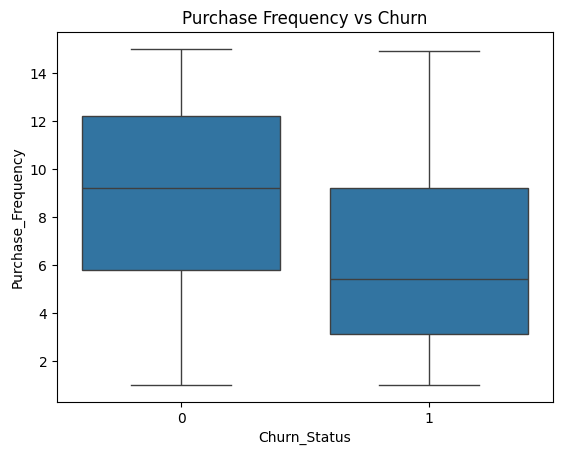

In [16]:
sns.boxplot(x='Churn_Status',y='Purchase_Frequency',data=data)
plt.title("Purchase Frequency vs Churn")
plt.show()

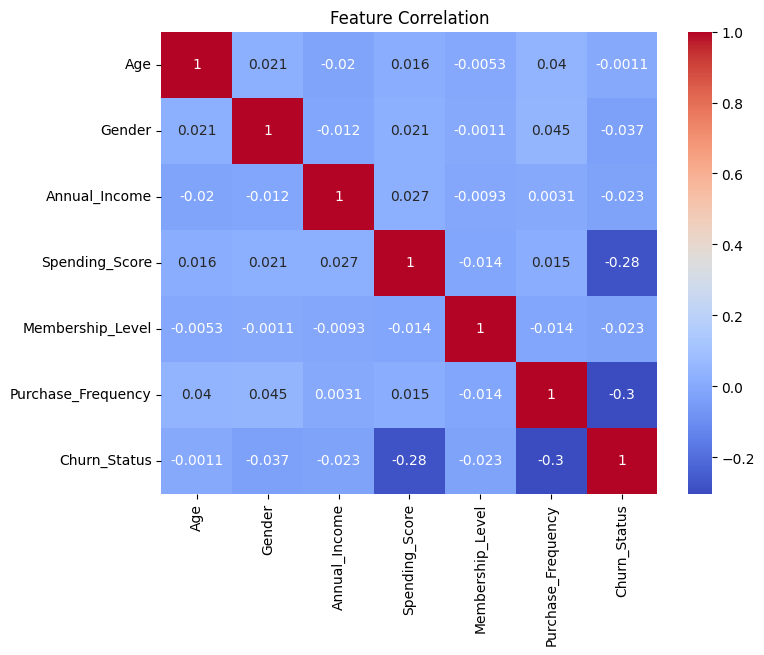

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(),annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [18]:
X=data.drop('Churn_Status',axis=1)
y=data['Churn_Status']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
from sklearn.metrics import accuracy_score
log_model=LogisticRegression(max_iter=1000,solver='lbfgs',random_state=42)
log_model.fit(X_train,y_train)
log_pred=log_model.predict(X_test)
log_acc=accuracy_score(y_test,log_pred)
print("Logistic Regression Accuracy:",log_acc)

Logistic Regression Accuracy: 0.7325


In [31]:
from sklearn.metrics import accuracy_score
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train,y_train)
rf_pred=rf_model.predict(X_test)
rf_acc=accuracy_score(y_test,rf_pred)
print("Random Forest Accuracy:",rf_acc)

Random Forest Accuracy: 0.7525


In [35]:
xgb_model=XGBClassifier(n_estimators=300,learning_rate=0.05,max_depth=5,random_state=42,subsample=0.8,colsample_bytree=0.8)
xgb_model.fit(X_train,y_train)
xgb_pred=xgb_model.predict(X_test)
xgb_acc=accuracy_score(y_test,xgb_pred)
print("XGBoost Accuracy:",xgb_acc)


XGBoost Accuracy: 0.7475


In [36]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 0.7625


In [37]:
from sklearn.metrics import accuracy_score,classification_report
print("Logistic Regression Report")
print(classification_report(y_test,log_pred))
print("Random Forest Report")
print(classification_report(y_test,rf_pred))
print("Gradient Boosting report")
print(classification_report(y_test,gb_pred))
print("XGBoost Report")
print(classification_report(y_test,xgb_pred))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.75      0.90      0.82       267
           1       0.67      0.39      0.49       133

    accuracy                           0.73       400
   macro avg       0.71      0.65      0.66       400
weighted avg       0.72      0.73      0.71       400

Random Forest Report
              precision    recall  f1-score   support

           0       0.74      0.96      0.84       267
           1       0.80      0.34      0.48       133

    accuracy                           0.75       400
   macro avg       0.77      0.65      0.66       400
weighted avg       0.76      0.75      0.72       400

Gradient Boosting report
              precision    recall  f1-score   support

           0       0.75      0.97      0.84       267
           1       0.84      0.35      0.50       133

    accuracy                           0.76       400
   macro avg       0.79      0.66      0.67       400
w

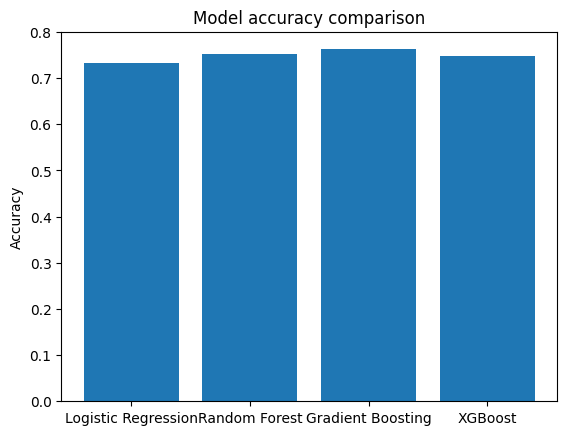

In [45]:
models=['Logistic Regression','Random Forest','Gradient Boosting','XGBoost']
accuracy=[log_acc,rf_acc,gb_acc,xgb_acc]
plt.bar(models,accuracy)
plt.title("Model accuracy comparison")
plt.ylabel("Accuracy")
plt.show()

In [39]:
importance=rf_model.feature_importances_
features=X.columns
importance_df=pd.DataFrame({
    'Feature':features,
    'Importance':importance}).sort_values(by='Importance',ascending=False)
print(importance_df)

              Feature  Importance
5  Purchase_Frequency    0.289497
3      Spending_Score    0.274959
2       Annual_Income    0.198353
0                 Age    0.159085
4    Membership_Level    0.051901
1              Gender    0.026205


A rule based system is implemented based on insights obtained from EDA. For example, customers with very low purchase are more likely to churn.

In [40]:
def rule_based_churn(row):
    if row['Purchase_Frequency']<5:
        return 1
    elif row['Spending_Score']<40 and row['Purchase_Frequency']<7:
        return 1
    elif row['Membership_Level']==0 and row['Purchase_Frequency']<6:
        return 1
    elif row['Annual_Income']<40000 and row['Purchase_Frequency']<5:
        return 1
    elif row['Spending_Score']>70 and row['Purchase_Frequency']>8:
        return 0
    elif row['Annual_Income']>80000 and row['Purchase_Frequency']>8:
        return 0
    else:
        return 0

In [41]:
data['Rule_Prediction']=data.apply(rule_based_churn,axis=1)

In [42]:
from sklearn.metrics import accuracy_score
rule_acc=accuracy_score(data['Churn_Status'],data['Rule_Prediction'])
print("Rule-Based Model Accuracy:",rule_acc)


Rule-Based Model Accuracy: 0.6835


In [43]:
comparison={
    "Logistic Regression":log_acc,
    "Random Forest":rf_acc,
    "Gradient Boosting":gb_acc,
    "XGBoost":xgb_acc,
    "Rule Based System":rule_acc}
comparison_df=pd.DataFrame(list(comparison.items()),columns=['Model','Accuracy'])
print(comparison_df)

                 Model  Accuracy
0  Logistic Regression    0.7325
1        Random Forest    0.7525
2    Gradient Boosting    0.7625
3              XGBoost    0.7475
4    Rule Based System    0.6835


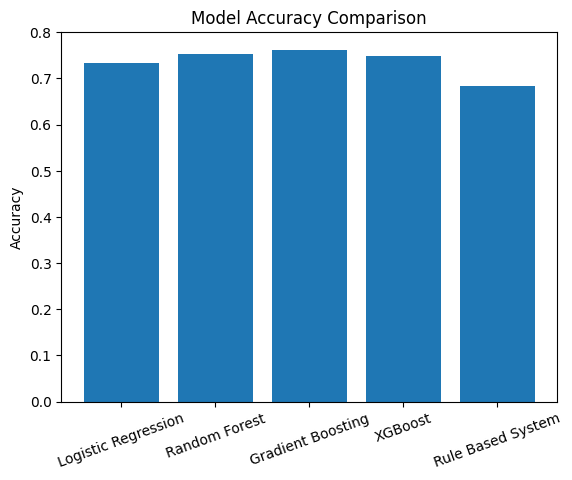

In [44]:
plt.bar(comparison_df['Model'],comparison_df['Accuracy'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

Among the tested models, Gradient Boosting technique achieved the highest accuracy for churn prediction. Feature important analysis showed that purchase frequency and spending score are the most influential factors affecting customer churn.